<a href="https://colab.research.google.com/github/aruna-31/Deep-Learning-practice-and-basic-projects/blob/main/Understanding_of_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("sonar data.csv", header=None)


X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values


In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)


scaler = StandardScaler()
X = scaler.fit_transform(X)

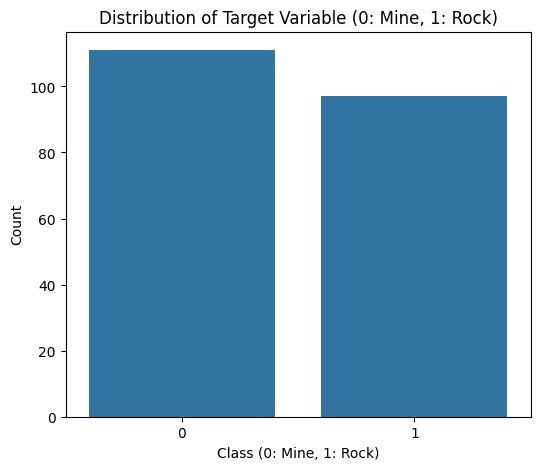

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (0: Mine, 1: Rock)')
plt.xlabel('Class (0: Mine, 1: Rock)')
plt.ylabel('Count')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

np.random.seed(42)

weights = np.random.randn(X_train.shape[1])
bias = 0

learning_rate = 0.01
epochs = 100

train_loss = []
train_accuracy = []

In [ ]:
for epoch in range(epochs):
    total_error = 0
    for i in range(len(X_train)):
        linear_output = np.dot(X_train[i], weights) + bias
        prediction = 1 if linear_output >= 0 else 0
        error = y_train[i] - prediction
        weights += learning_rate * error * X_train[i]
        bias += learning_rate * error

        total_error += error**2

    train_loss.append(total_error / len(X_train))

    predictions = []

    for sample in X_train:
        output = np.dot(sample, weights) + bias
        predictions.append(1 if output >= 0 else 0)

    accuracy = np.mean(np.array(predictions) == y_train)
    train_accuracy.append(accuracy)

    print(f"Epoch {epoch+1:3d} | Loss = {train_loss[-1]:.4f} | Accuracy = {accuracy:.4f}")




Epoch   1 | Loss = 0.4277 | Accuracy = 0.6325
Epoch   2 | Loss = 0.3855 | Accuracy = 0.6145
Epoch   3 | Loss = 0.3554 | Accuracy = 0.6446
Epoch   4 | Loss = 0.3193 | Accuracy = 0.6928
Epoch   5 | Loss = 0.2952 | Accuracy = 0.7169
Epoch   6 | Loss = 0.2771 | Accuracy = 0.7289
Epoch   7 | Loss = 0.2229 | Accuracy = 0.7530
Epoch   8 | Loss = 0.2229 | Accuracy = 0.7952
Epoch   9 | Loss = 0.2169 | Accuracy = 0.8072
Epoch  10 | Loss = 0.1988 | Accuracy = 0.8253
Epoch  11 | Loss = 0.2108 | Accuracy = 0.8072
Epoch  12 | Loss = 0.1928 | Accuracy = 0.8253
Epoch  13 | Loss = 0.1747 | Accuracy = 0.8373
Epoch  14 | Loss = 0.1928 | Accuracy = 0.8313
Epoch  15 | Loss = 0.1687 | Accuracy = 0.8434
Epoch  16 | Loss = 0.1807 | Accuracy = 0.8554
Epoch  17 | Loss = 0.1506 | Accuracy = 0.8494
Epoch  18 | Loss = 0.1627 | Accuracy = 0.8735
Epoch  19 | Loss = 0.1446 | Accuracy = 0.8373
Epoch  20 | Loss = 0.1627 | Accuracy = 0.8735
Epoch  21 | Loss = 0.1627 | Accuracy = 0.8554
Epoch  22 | Loss = 0.1747 | Accura


Final Test Accuracy : 0.7380952380952381


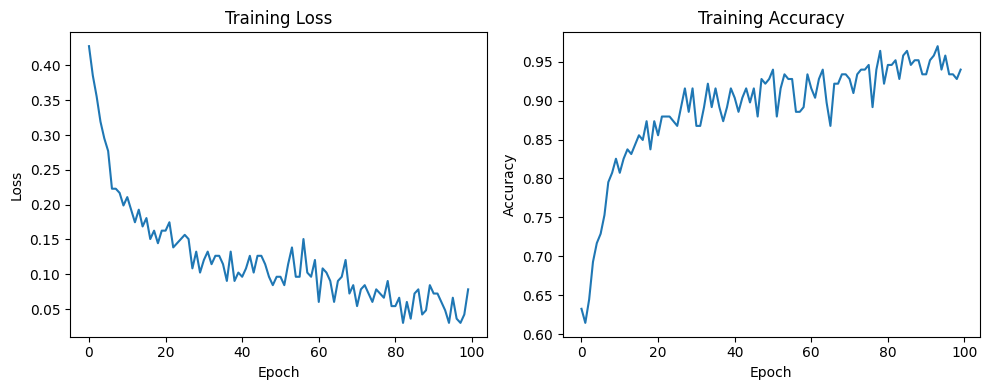

In [ ]:
test_predictions = []
for sample in X_test:
    output = np.dot(sample, weights) + bias
    test_predictions.append(1 if output >= 0 else 0)

test_predictions = np.array(test_predictions)

test_accuracy = np.mean(test_predictions == y_test)

print("\nFinal Test Accuracy :", test_accuracy)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accuracy)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()